# Guided Exercise — SOLUTION

**Scenario:** The bank's operations team wants a working forecast of daily ATM withdrawals so
they can plan cash-loading schedules more efficiently.

This is the fully worked solution to `exercises/forecasting_exercise.ipynb`. Try the exercise
yourself first — you'll learn more that way!

## Step 1 — Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (11, 5)

df = pd.read_csv("../data/bank_cash_withdrawal_timeseries.csv", parse_dates=["Date"])
df.shape

(730, 6)

## Step 2 — Sort by date

In [2]:
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,WithdrawalAmount,DayOfWeek,IsWeekend,Month,IsHolidayIndicator
0,2023-01-01,5202245,Sunday,1,1,1
1,2023-01-02,24686212,Monday,0,1,0
2,2023-01-03,25553319,Tuesday,0,1,0
3,2023-01-04,19900094,Wednesday,0,1,0
4,2023-01-05,18711187,Thursday,0,1,0


## Step 3 — Visualize the series

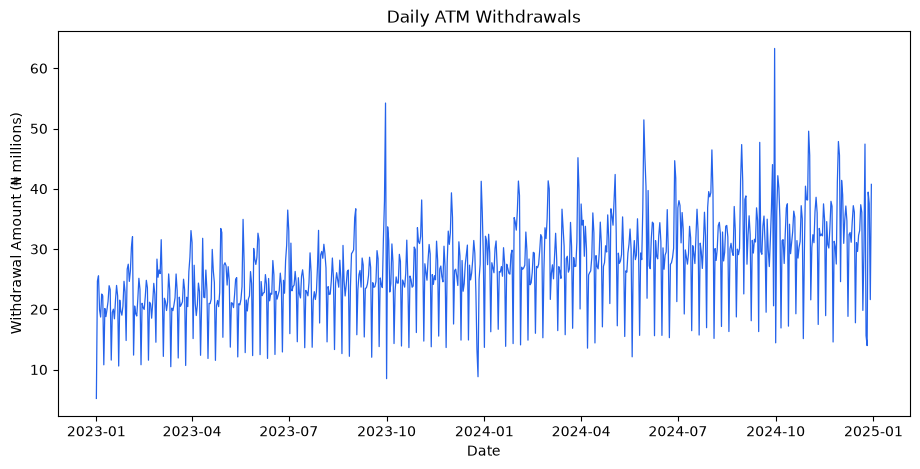

In [3]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["WithdrawalAmount"] / 1e6, color="#2563EB", linewidth=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Daily ATM Withdrawals")
plt.show()

A gentle upward trend and a clear repeating weekly rhythm are both visible, along with a handful of sharp spikes/dips (holidays and unexplained events).

## Step 4 — Create lag features

In [4]:
df["Lag_1"] = df["WithdrawalAmount"].shift(1)
df["Lag_7"] = df["WithdrawalAmount"].shift(7)

## Step 5 — Create calendar features

In [5]:
df["DayOfWeekNum"] = df["Date"].dt.dayofweek
df["MonthNum"] = df["Date"].dt.month

df = df.dropna().reset_index(drop=True)
df.shape

(723, 10)

## Step 6 — Time-based train/test split

In [6]:
TEST_DAYS = 45

split_index = len(df) - TEST_DAYS
train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Train: {len(train)} rows, Test: {len(test)} rows")

Train: 678 rows, Test: 45 rows


## Step 7 — Build a naive baseline

In [7]:
naive_mae = mean_absolute_error(test["WithdrawalAmount"], test["Lag_1"])
print(f"Naive baseline MAE: {naive_mae:,.0f}")

Naive baseline MAE: 8,669,555


## Step 8 — Train a forecasting model

In [8]:
feature_cols = ["Lag_1", "Lag_7", "DayOfWeekNum", "MonthNum", "IsWeekend"]

model = LinearRegression()
model.fit(train[feature_cols], train["WithdrawalAmount"])

forecast = model.predict(test[feature_cols])

## Step 9 — Evaluate: MAE, RMSE, MAPE

In [9]:
model_mae = mean_absolute_error(test["WithdrawalAmount"], forecast)
model_rmse = root_mean_squared_error(test["WithdrawalAmount"], forecast)
model_mape = mean_absolute_percentage_error(test["WithdrawalAmount"], forecast)

print(f"Model MAE: {model_mae:,.0f}   RMSE: {model_rmse:,.0f}   MAPE: {model_mape*100:.1f}%")
print(f"Naive MAE: {naive_mae:,.0f}")

Model MAE: 4,735,576   RMSE: 6,652,988   MAPE: 17.6%
Naive MAE: 8,669,555


## Step 10 — Visualize actual vs. forecast

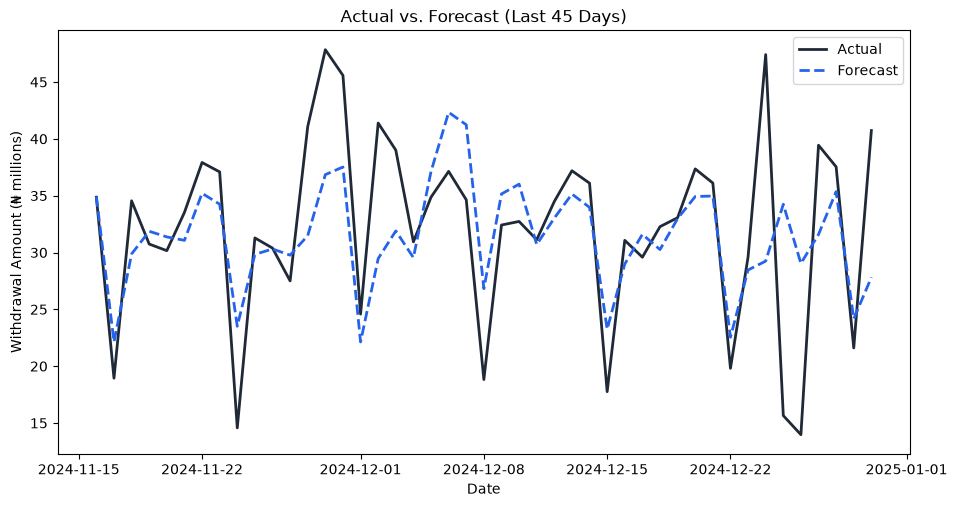

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(test["Date"], test["WithdrawalAmount"] / 1e6, color="#1F2937", linewidth=2, label="Actual")
ax.plot(test["Date"], forecast / 1e6, color="#2563EB", linewidth=2, linestyle="--", label="Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Actual vs. Forecast (Last 45 Days)")
ax.legend()
plt.show()

## Step 11 — Answers

**1. Did your model beat the naive baseline? By how much?**
Yes — the model's MAE is noticeably lower than the naive baseline's MAE (print the two numbers
above to see the exact improvement on this run; it's typically a 35-45% reduction).

**2. Is there a visible trend and/or weekly seasonality?**
Yes to both. There's a gentle upward trend across the two years, and a strong, consistent
weekly pattern — busier around Fridays/Saturdays, much quieter on Sundays.

**3. Where does the forecast track well vs. struggle?**
The forecast follows the general weekly up-and-down rhythm closely. It struggles most on days
with holiday effects or unexplained spikes, since no feature in this simpler feature set
explicitly flags those events (an interesting next step would be adding
`IsHolidayIndicator` as a feature).

**4. What should the bank's cash operations team do?**
Use the forecast to plan cash-loading ahead of predictably busy periods (Fridays, month-end
paydays) and reduce loading on predictably quiet days (Sundays) — while treating flagged
holiday periods as special cases needing manual review rather than trusting the automated
forecast blindly on those specific days.